#### Project 1: General EDA

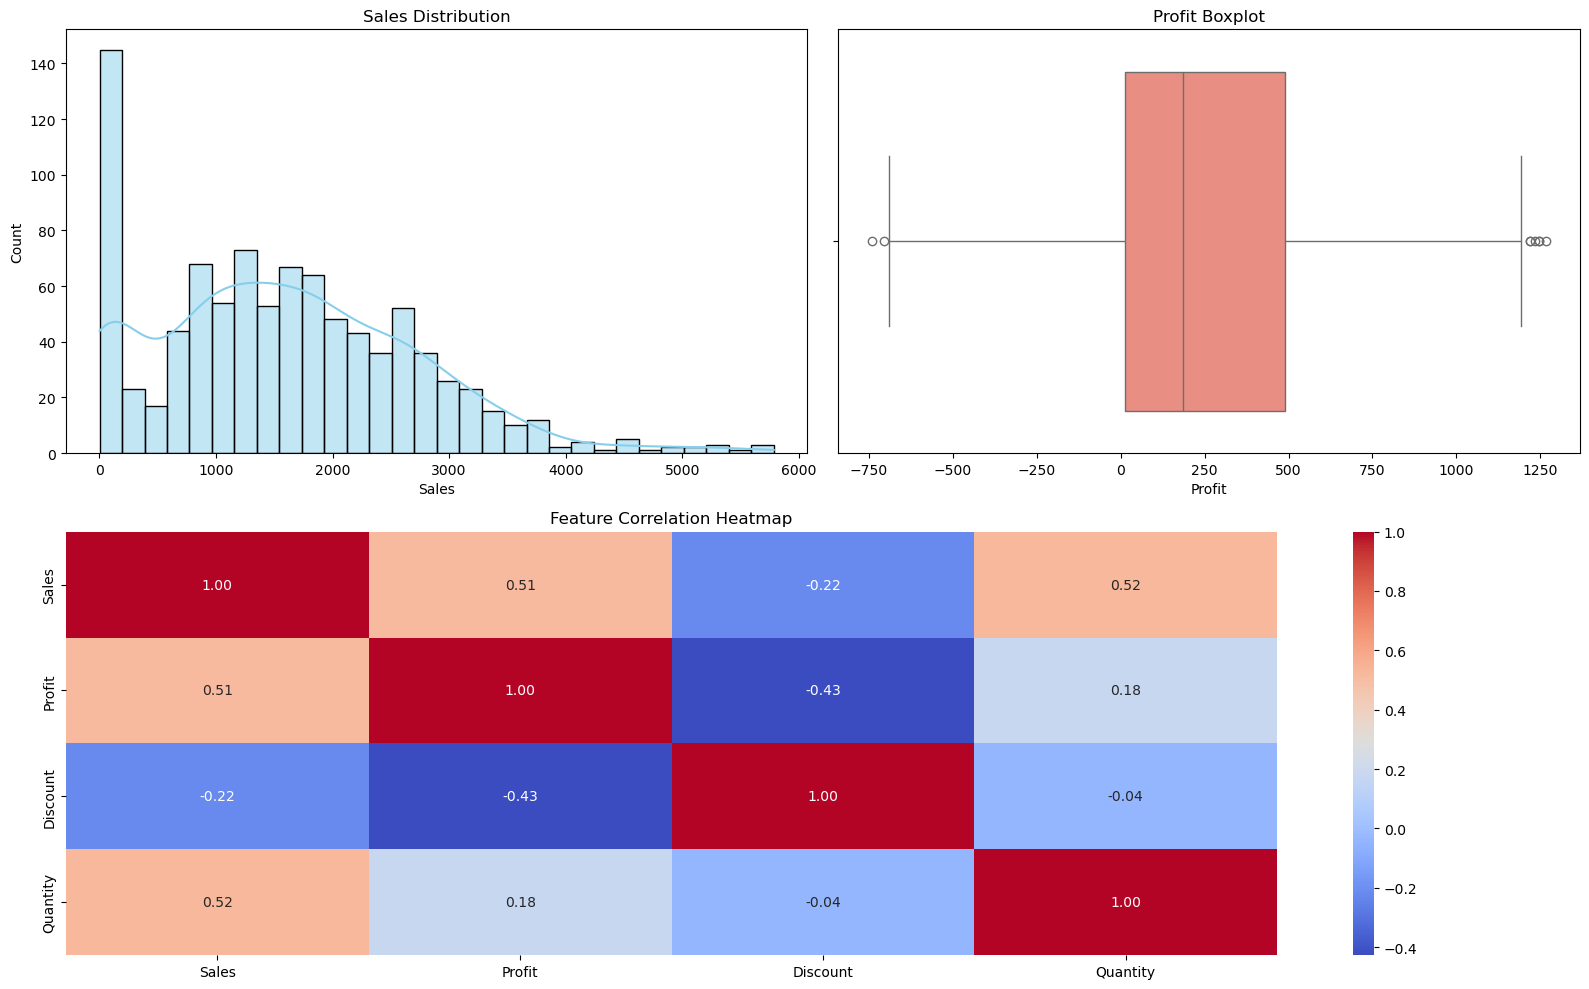


--- Summary Statistics ---
           ï»¿Row ID   Postal Code        Sales    Quantity    Discount  \
count    933.000000    191.000000   933.000000  933.000000  933.000000   
mean   25115.124330  54198.000000  1584.928092    5.345123    0.084084   
std    12911.695436  33844.022441  1117.996160    2.592261    0.134699   
min       58.000000   2920.000000     1.910000    1.000000    0.000000   
25%    15203.000000  19134.000000   780.610000    3.000000    0.000000   
50%    25271.000000  60653.000000  1513.560000    5.000000    0.000000   
75%    34731.000000  89509.500000  2325.280000    7.000000    0.150000   
max    51284.000000  98198.000000  5785.020000   14.000000    0.800000   

            Profit  Shipping Cost  
count   933.000000     933.000000  
mean    271.153730     265.994847  
std     356.715727     176.258789  
min    -740.300000       1.070000  
25%      12.690000     207.892000  
50%     184.950000     255.690000  
75%     488.600000     340.090000  
max    1267.7700

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Load dataset from raw GitHub URL
url = "https://github.com/yannie28/Global-Superstore/raw/refs/heads/master/Global_Superstore(CSV).csv"
df = pd.read_csv(url, encoding='ISO-8859-1')  # Use ISO encoding to handle special characters

# ----------------- Data Cleaning -----------------
# Fill missing values
df.fillna({
    'Sales': df['Sales'].mean(),
    'Profit': df['Profit'].mean(),
    'Discount': df['Discount'].mean(),
    'Quantity': df['Quantity'].median(),
    'Region': 'Unknown',
    'Category': 'Unknown'
}, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle outliers in 'Profit' using IQR
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['Profit'] < Q1 - 1.5 * IQR) | (df['Profit'] > Q3 + 1.5 * IQR))]

# ----------------- Statistical Analysis -----------------
summary = df.describe()
correlation = df[['Sales', 'Profit', 'Discount', 'Quantity']].corr()

# ----------------- Data Visualizations -----------------
plt.figure(figsize=(16, 10))

# Histogram - Sales
plt.subplot(2, 2, 1)
sns.histplot(df['Sales'], bins=30, kde=True, color='skyblue')
plt.title("Sales Distribution")

# Boxplot - Profit
plt.subplot(2, 2, 2)
sns.boxplot(x=df['Profit'], color='salmon')
plt.title("Profit Boxplot")

# Heatmap - Correlation
plt.subplot(2, 1, 2)
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

# ----------------- Print Summary -----------------
print("\n--- Summary Statistics ---\n", summary)
print("\n--- Correlation Matrix ---\n", correlation)

####  Project 2: Sales Performance Analysis

Shape: (369, 6)
Missing Values:
 date        0
product     0
category    0
price       2
quantity    1
revenue     1
dtype: int64
Data Types:
 date         object
product      object
category     object
price       float64
quantity    float64
revenue     float64
dtype: object


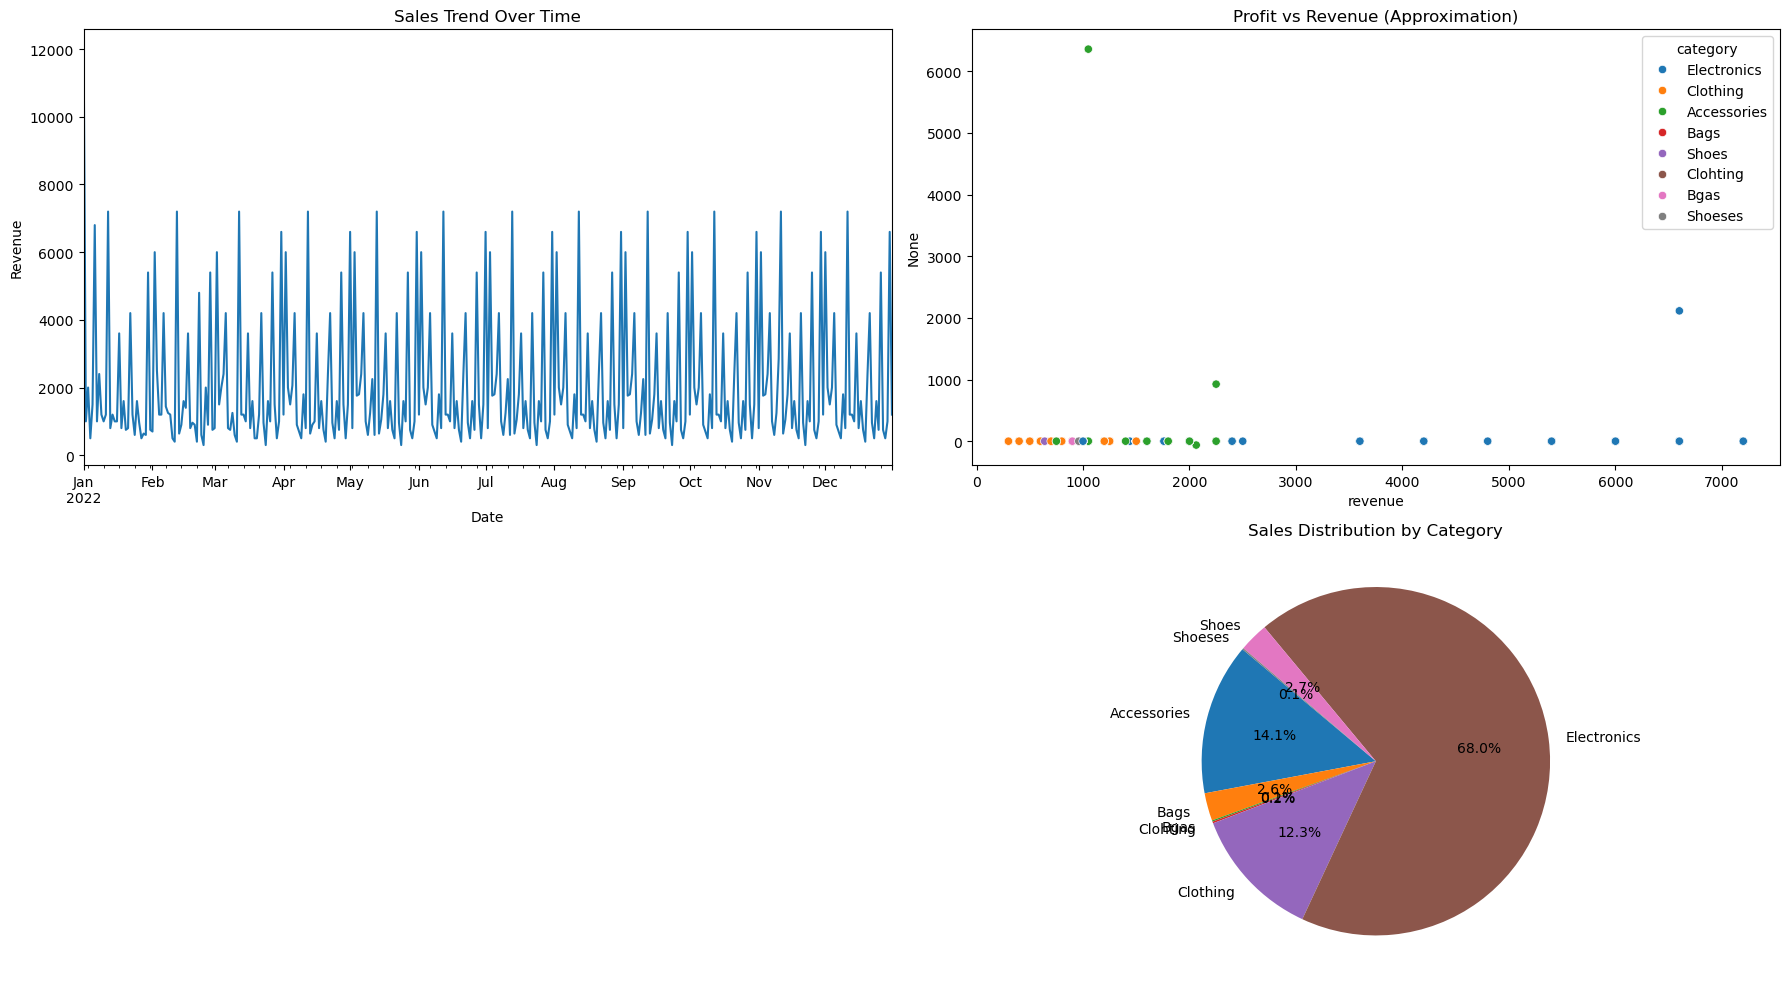


--- Linear Regression Model Evaluation ---
R² Score: -0.00015776407784939828
RMSE: 1925.020552973593

--- Insights & Recommendations ---
Top Categories by Revenue:
 category
Electronics    516080.000000
Accessories    106763.024523
Clothing        93150.000000
Shoes           20640.000000
Bags            19500.000000
Name: revenue, dtype: float64


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset from raw GitHub URL
url = "https://github.com/intern2grow/sales-data-analysis/raw/main/sales_data.csv"
df = pd.read_csv(url)

# ----------------- Data Exploration -----------------
print("Shape:", df.shape)
print("Missing Values:\n", df.isnull().sum())
print("Data Types:\n", df.dtypes)

# ----------------- Data Cleaning -----------------
df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)
df['date'] = pd.to_datetime(df['date'])

# ----------------- Exploratory Data Analysis -----------------
plt.figure(figsize=(18, 10))

# Time Series Plot - Sales over Time
plt.subplot(2, 2, 1)
df.groupby('date')['revenue'].sum().plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")

# Scatter Plot - Profit vs Discount
plt.subplot(2, 2, 2)
sns.scatterplot(x=df['revenue'], y=df['price']*df['quantity'] - df['revenue'], hue=df['category'])
plt.title("Profit vs Revenue (Approximation)")

# Bar Plot - Sales by Region (if Region column exists)
if 'region' in df.columns:
    plt.subplot(2, 2, 3)
    df.groupby('region')['revenue'].sum().plot(kind='bar', color='teal')
    plt.title("Sales by Region")

# Pie Chart - Sales by Category
plt.subplot(2, 2, 4)
category_sales = df.groupby('category')['revenue'].sum()
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=140)
plt.title("Sales Distribution by Category")

plt.tight_layout()
plt.show()

# ----------------- Predictive Modeling -----------------
# Features: Profit (approximated), Discount (if available)
df['profit'] = df['price'] * df['quantity'] - df['revenue']
features = ['profit']
if 'discount' in df.columns:
    features.append('discount')

X = df[features]
y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Model Evaluation
print("\n--- Linear Regression Model Evaluation ---")
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# ----------------- Insights -----------------
print("\n--- Insights & Recommendations ---")
print("Top Categories by Revenue:\n", df.groupby('category')['revenue'].sum().sort_values(ascending=False).head())
if 'discount' in df.columns:
    print("Average Discount on High Revenue Sales:\n", df[df['revenue'] > df['revenue'].mean()]['discount'].mean())